# Argument realization in an Ojibwe corpus: word order

In this notebook, we will attempt to parse the word order of overt nominals, currently touching 2 cases:
1. Transitive (Both arguments overt): Without splitting on specific attributes, what counts do we see of VOS, VSO, SVO etc.
2. One overt argument: For now just counting overall, will split on verb paradigm after.
3. Direct-inverse: Taking only 3-3 VTAs into account, what word orders do we see for the direct and inverse. 

### Part 1: Transitive word order counts

Scan the `.conllu` file for word order information. 

In [10]:
from grammar_modules.disambiguation import REPO_ROOT
from corpus_abstraction import *

CORPUS_PATH = REPO_ROOT / "data" / "treebanks" / "Chi_mewinzha_full.conllu"

corpus = analyze_corpus()

inverse_predicates = [
    predicate
    for predicate in corpus["predicates"]
    if predicate["predicate"]["direction"] == "inverse"
]

conjunct_orders = Counter(
    predicate["head_order"]
    for predicate in corpus["predicates"]
    if predicate["predicate"]["order"] == "conjunct"
)
print(inverse_predicates)
print(conjunct_orders)


[{'predicate_id': ('4', 3), 'sent_id': '4', 'text': 'Nimaamaanaan iko niwiindamaagonaanig gaa-inakamigak iidog .', 'eng': 'Our mom would tell us about what happened.', 'predicate_token': {'id': 3, 'form': 'niwiindamaagonaanig', 'lemma': 'wiindamaw', 'upos': 'VERB', 'xpos': 'VTA|Ind|Pos|Neu|3PlProxSubj|ExclObj|VERB', 'feats': None, 'head': 0, 'deprel': 'root', 'deps': None, 'misc': None}, 'predicate_text': 'niwiindamaagonaanig', 'lemma': 'wiindamaw', 'predicate': {'verb_class': 'VTA', 'order': 'independent', 'mode': 'neutral', 'polarity': 'positive', 'subject_agreement': '3PlProx', 'object_agreement': 'Excl', 'direction': 'inverse'}, 'arguments': [], 'has_overt_subject': False, 'has_overt_object': False, 'realization_pattern': 'NO_OVERT_ARGUMENTS', 'head_order': 'V', 'is_root': True, 'is_relative': False, 'is_argumental': False, 'relation_to_governor': 'root', 'governing_predicate_id': None}, {'predicate_id': ('54', 2), 'sent_id': '54', 'text': "Mii-ko gaa-izhi-gaganoonigooyaan gaye nii

In [15]:
from collections import Counter

from corpus_abstraction import analyze_corpus


corpus = analyze_corpus()


def is_third_proximate(agreement):
    return (
        agreement is not None
        and agreement.startswith("3")
        and "Obv" not in agreement
    )


def is_third_obviative(agreement):
    return (
        agreement is not None
        and agreement.startswith("3")
        and "Obv" in agreement
    )


def has_both_overt_arguments(predicate):
    return (
        predicate["has_overt_subject"]
        and predicate["has_overt_object"]
    )


inverse_3obv_to_3prox = [
    predicate
    for predicate in corpus["predicates"]
    if predicate["predicate"]["verb_class"] == "VTA"
    and predicate["predicate"]["direction"] == "inverse"
    and is_third_obviative(
        predicate["predicate"]["subject_agreement"]
    )
    and is_third_proximate(
        predicate["predicate"]["object_agreement"]
    )
    and has_both_overt_arguments(predicate)
]


direct_3prox_to_3obv = [
    predicate
    for predicate in corpus["predicates"]
    if predicate["predicate"]["verb_class"] == "VTA"
    and predicate["predicate"]["direction"] == "direct"
    and is_third_proximate(
        predicate["predicate"]["subject_agreement"]
    )
    and is_third_obviative(
        predicate["predicate"]["object_agreement"]
    )
    and has_both_overt_arguments(predicate)
]


inverse_orders = Counter(
    predicate["head_order"]
    for predicate in inverse_3obv_to_3prox
)

direct_orders = Counter(
    predicate["head_order"]
    for predicate in direct_3prox_to_3obv
)

for predicate in direct_3prox_to_3obv:
    if predicate["head_order"] == "MULTIPLE_ARGUMENTS":
        print(predicate)


print("3'→3 inverse clauses:")
print(inverse_orders)
print(f"Total: {len(inverse_3obv_to_3prox)}")

print("\n3→3' direct clauses:")
print(direct_orders)
print(f"Total: {len(direct_3prox_to_3obv)}")

{'predicate_id': ('140', 8), 'sent_id': '140', 'text': 'Gaawiin igaye ingiw asaawensag , gaawiin awiiya ogii-pabaamenimaasiwaawaan iniw giigoonyan .', 'eng': 'Nowadays, the Indians are always sick.', 'predicate_token': {'id': 8, 'form': 'ogii-pabaamenimaasiwaawaan', 'lemma': 'babaamenim', 'upos': 'VERB', 'xpos': 'PVTense/gii|VTA|Ind|Neg|Neu|3PlProxSubj|3PlObvObj|VERB', 'feats': None, 'head': 0, 'deprel': 'root', 'deps': None, 'misc': None}, 'predicate_text': 'ogii-pabaamenimaasiwaawaan', 'lemma': 'babaamenim', 'predicate': {'verb_class': 'VTA', 'order': 'independent', 'mode': 'neutral', 'polarity': 'negative', 'subject_agreement': '3PlProx', 'object_agreement': '3PlObv', 'direction': 'direct'}, 'arguments': [{'sent_id': '140', 'text': 'Gaawiin igaye ingiw asaawensag , gaawiin awiiya ogii-pabaamenimaasiwaawaan iniw giigoonyan .', 'eng': 'Nowadays, the Indians are always sick.', 'predicate_id': ('140', 8), 'argument_predicate_id': None, 'relation': 'nsubj', 'role': 'subject', 'argument_t

In [17]:
for predicate in corpus["predicates"]:
    if predicate["is_relative"] and predicate["is_argumental"]:
        print(predicate)

{'predicate_id': ('27', 8), 'sent_id': '27', 'text': "Mii giiwenh mewinzha iko iw gaa-izhi-noondamaan , gaa-izhi-noondamaan gii-gichi-aya'aawiwag ingiw .", 'eng': 'That’s what I heard from the elders a long time ago.', 'predicate_token': {'id': 8, 'form': 'gaa-izhi-noondamaan', 'lemma': 'noondan', 'upos': 'VERB', 'xpos': 'PVSub/gaa|PVRel/izhi|VTI|Cnj|Pos|Neu|1SgSubj|0SgObj|RelCl|VERB', 'feats': None, 'head': 6, 'deprel': 'obj', 'deps': None, 'misc': None}, 'predicate_text': 'gaa-izhi-noondamaan', 'lemma': 'noondan', 'predicate': {'verb_class': 'VTI', 'order': 'conjunct', 'mode': 'neutral', 'polarity': 'positive', 'subject_agreement': '1Sg', 'object_agreement': '0Sg', 'direction': None}, 'arguments': [], 'has_overt_subject': False, 'has_overt_object': False, 'realization_pattern': 'NO_OVERT_ARGUMENTS', 'head_order': 'V', 'is_root': False, 'is_relative': True, 'is_argumental': True, 'relation_to_governor': 'obj', 'governing_predicate_id': ('27', 6)}
{'predicate_id': ('97', 12), 'sent_id'

In [18]:
from grammar_modules.disambiguation import REPO_ROOT

CORPUS_PATH = REPO_ROOT / "data" / "treebanks" / "Chi_mewinzha_full.conllu"

from conllu import parse_incr

VSO_count = VOS_count = SVO_count = OVS_count = SOV_count = OSV_count = 0

# TODO: for now I only collect 1 subject and 1 object per sentence
#       and make sure that head matches. not good for embedded clauses etc.
with open(CORPUS_PATH, encoding="utf-8") as f:
    for i, sent in enumerate(parse_incr(f)):
        subjects = [] # list of tuples of ID, HEAD
        objects = [] # list of tuples of ID, HEAD

        for tok in sent:
            xpos = tok.get("xpos")
            if not xpos:
                continue
            # collect subjects and their head
            if tok["deprel"] == "nsubj":
                subj = (tok["id"], tok["head"])
                subjects.append(subj)
            # collect objects and their head
            if tok["deprel"] == "obj":
                obj = (tok["id"], tok["head"])
                objects.append(obj)

        # check that at least one subject and object are found
        if len(subjects) < 1 or len(objects) < 1:
            continue
        
        # build up subj/obj pairs where the head is the same ID
        subj_obj_pairs = []
        for subj in subjects:
            for obj in objects: 
                if subj[1] == obj[1]:
                    subj_obj_pairs.append((subj, obj))
        
        for subj, obj in subj_obj_pairs:
            # collect counts per case
            # VSO 
            if subj[0] > subj[1] and subj[0] < obj[0] and obj[0] > obj[1]:
                print(f"Sentence {i+1} is VSO: {sent.metadata.get("text")}")
                VSO_count += 1
                continue
            # VOS
            if subj[0] > subj[1] and subj[0] > obj[0] and obj[0] > obj[1]:
                print(f"Sentence {i+1} is VOS: {sent.metadata.get("text")}")
                VOS_count += 1
                continue
            # SVO 
            if subj[0] < subj[1] and obj[0] > obj[1]:
                print(f"Sentence {i+1} is SVO: {sent.metadata.get("text")}")
                SVO_count += 1
                continue
            # OVS 
            if subj[0] > subj[1] and obj[0] < obj[1]:
                print(f"Sentence {i+1} is OVS: {sent.metadata.get("text")}")
                OVS_count += 1
                continue
            # SOV 
            if subj[0] < subj[1] and subj[0] < obj[0] and obj[0] < obj[1]:
                print(f"Sentence {i+1} is SOV: {sent.metadata.get("text")}")
                SOV_count += 1
                continue
            # OSV 
            if subj[0] < subj[1] and subj[0] > obj[0] and obj[0] < obj[1]:
                print(f"Sentence {i+1} is OSV: {sent.metadata.get("text")}")
                OSV_count += 1
                continue

total_count = VSO_count + VOS_count + SVO_count + OVS_count + SOV_count + OSV_count
        
print(
    f"Total sentences w/ two overt arguments: {total_count}",
    f"Total VSO: {VSO_count}",
    f"Total VOS: {VOS_count}",
    f"Total SVO: {SVO_count}",
    f"Total OVS: {OVS_count}",
    f"Total SOV: {SOV_count}",
    f"Total OSV: {OSV_count}",
    sep="\n",
)


Sentence 28 is VSO: ingii-pizindawaag niin ingiw chi-aya'aag .
Sentence 32 is VSO: ingii-pizindawaag niin ingiw nichi-anishinaabemag .
Sentence 69 is SOV: gaawiin dash ge niin gegoo ingikendanziin , mashkiki gii-ozhitoowaad .
Sentence 70 is OVS: akina gegoo ogii-gikendaanaawaa mewinzha anishinaabeg .
Sentence 73 is OSV: miinawaa bagida'waawaad miinawaa iniw ayi'iing nibiikaang nimaamaa ondinaad iniw ayi'iin ozhitood ayi'iin apishimonan ozhitood .
Sentence 73 is SVO: miinawaa bagida'waawaad miinawaa iniw ayi'iing nibiikaang nimaamaa ondinaad iniw ayi'iin ozhitood ayi'iin apishimonan ozhitood .
Sentence 103 is OSV: miinawaa , mii iw apii anishinaabeg memoowaad i'iw mashkiki miinawaa iw wiigwaas .
Sentence 103 is SVO: miinawaa , mii iw apii anishinaabeg memoowaad i'iw mashkiki miinawaa iw wiigwaas .
Sentence 103 is SVO: miinawaa , mii iw apii anishinaabeg memoowaad i'iw mashkiki miinawaa iw wiigwaas .
Sentence 120 is OSV: akina gegoo wiinawaa ogii-ozhitoonaawaa .
Sentence 140 is SVO: gaaw

In [19]:
# create stats tables
import pandas as pd

stats = [
    {"word order": "VSO", "total": VSO_count,},
    {"word order": "VOS", "total": VOS_count,},
    {"word order": "SVO", "total": SVO_count,},
    {"word order": "OVS", "total": OVS_count,},
    {"word order": "SOV", "total": SOV_count,},
    {"word order": "OSV", "total": OSV_count,},
]
df = pd.DataFrame(stats)
df["ratio"] = round(df["total"] / total_count, 2)

print(df.to_string(index=False))

word order  total  ratio
       VSO      4   0.12
       VOS      1   0.03
       SVO     14   0.44
       OVS      6   0.19
       SOV      2   0.06
       OSV      5   0.16


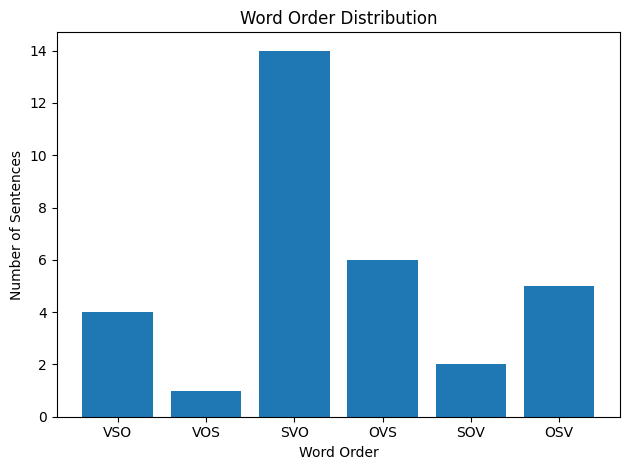

In [20]:
# Simple bar chart for word order distribution

import matplotlib.pyplot as plt
import numpy as np

# Data
orders = ["VSO", "VOS", "SVO", "OVS", "SOV", "OSV"]
totals = np.array([4, 1, 14, 6, 2, 5])

# Create plot
plt.figure()
plt.bar(orders, totals)

plt.xlabel("Word Order")
plt.ylabel("Number of Sentences")
plt.title("Word Order Distribution")

plt.tight_layout()
plt.show()


### Part 2: One overt argument word order

Similar logic to above, collect counts for different orders.

In [21]:
from grammar_modules.disambiguation import REPO_ROOT

CORPUS_PATH = REPO_ROOT / "data" / "treebanks" / "Chi_mewinzha_full.conllu"

from conllu import parse_incr

VS_count = SV_count = VO_count = OV_count = 0

# TODO: here we collect more than 1 case per sentence
#       also still not splitting on verb paradigm
with open(CORPUS_PATH, encoding="utf-8") as f:
    for i, sent in enumerate(parse_incr(f)):
        subjects = [] # list of tuples of ID, HEAD
        objects = [] # list of tuples of ID, HEAD
        for tok in sent:
            xpos = tok.get("xpos")
            if not xpos:
                continue
            # collect subjects and their head
            if tok["deprel"] == "nsubj":
                subj = (tok["id"], tok["head"])
                subjects.append(subj)
            # collect objects and their head
            if tok["deprel"] == "obj":
                obj = (tok["id"], tok["head"])
                objects.append(obj)

        
        # collect counts per case
        for subj in subjects:
            if subj[0] > subj[1]:
                VS_count += 1
            elif subj[0] < subj[1]:
                SV_count += 1
        
        for obj in objects:
            if obj[0] > obj[1]:
                VO_count += 1
            elif obj[0] < obj[1]:
                OV_count += 1
        
print(
    f"Total VS: {VS_count}",
    f"Total SV: {SV_count}",
    f"Total VO: {VO_count}",
    f"Total OV: {OV_count}",
    sep="\n",
)


Total VS: 119
Total SV: 109
Total VO: 161
Total OV: 111


In [22]:
# create stats tables
import pandas as pd

stats = [
    {"word order": "VS", "total": VS_count,},
    {"word order": "SV", "total": SV_count,},
    {"word order": "VO", "total": VO_count,},
    {"word order": "OV", "total": OV_count,},
]
df = pd.DataFrame(stats)
print(df.to_string(index=False))

word order  total
        VS    119
        SV    109
        VO    161
        OV    111


In [ ]:
from collections import Counter

from corpus_abstraction import analyze_corpus


corpus = analyze_corpus()


def is_third_proximate(agreement):
    return (
        agreement is not None
        and agreement.startswith("3")
        and "Obv" not in agreement
    )


def is_third_obviative(agreement):
    return (
        agreement is not None
        and agreement.startswith("3")
        and "Obv" in agreement
    )


def has_both_overt_arguments(predicate):
    return (
        predicate["has_overt_subject"]
        and predicate["has_overt_object"]
    )


inverse_3obv_to_3prox = [
    predicate
    for predicate in corpus["predicates"]
    if predicate["predicate"]["verb_class"] == "VTA"
    and predicate["predicate"]["direction"] == "inverse"
    and is_third_obviative(
        predicate["predicate"]["subject_agreement"]
    )
    and is_third_proximate(
        predicate["predicate"]["object_agreement"]
    )
    and has_both_overt_arguments(predicate)
]


direct_3prox_to_3obv = [
    predicate
    for predicate in corpus["predicates"]
    if predicate["predicate"]["verb_class"] == "VTA"
    and predicate["predicate"]["direction"] == "direct"
    and is_third_proximate(
        predicate["predicate"]["subject_agreement"]
    )
    and is_third_obviative(
        predicate["predicate"]["object_agreement"]
    )
    and has_both_overt_arguments(predicate)
]


inverse_orders = Counter(
    predicate["head_order"]
    for predicate in inverse_3obv_to_3prox
)

direct_orders = Counter(
    predicate["head_order"]
    for predicate in direct_3prox_to_3obv
)

for predicate in direct_3prox_to_3obv:
    if predicate["head_order"] == "MULTIPLE_ARGUMENTS":
        print(predicate)


print("3'→3 inverse clauses:")
print(inverse_orders)
print(f"Total: {len(inverse_3obv_to_3prox)}")

print("\n3→3' direct clauses:")
print(direct_orders)
print(f"Total: {len(direct_3prox_to_3obv)}")

{'predicate_id': ('140', 8), 'sent_id': '140', 'text': 'Gaawiin igaye ingiw asaawensag , gaawiin awiiya ogii-pabaamenimaasiwaawaan iniw giigoonyan .', 'eng': 'Nowadays, the Indians are always sick.', 'predicate_token': {'id': 8, 'form': 'ogii-pabaamenimaasiwaawaan', 'lemma': 'babaamenim', 'upos': 'VERB', 'xpos': 'PVTense/gii|VTA|Ind|Neg|Neu|3PlProxSubj|3PlObvObj|VERB', 'feats': None, 'head': 0, 'deprel': 'root', 'deps': None, 'misc': None}, 'predicate_text': 'ogii-pabaamenimaasiwaawaan', 'lemma': 'babaamenim', 'predicate': {'verb_class': 'VTA', 'order': 'independent', 'mode': 'neutral', 'polarity': 'negative', 'subject_agreement': '3PlProx', 'object_agreement': '3PlObv', 'direction': 'direct'}, 'arguments': [{'sent_id': '140', 'text': 'Gaawiin igaye ingiw asaawensag , gaawiin awiiya ogii-pabaamenimaasiwaawaan iniw giigoonyan .', 'eng': 'Nowadays, the Indians are always sick.', 'predicate_id': ('140', 8), 'argument_predicate_id': None, 'relation': 'nsubj', 'role': 'subject', 'argument_t

### Part 3: Word order of direct and inverse

Sampling only VTA verbs, count word orders splitting on direct and inverse morphology.

In [ ]:
from grammar_modules.disambiguation import REPO_ROOT

CORPUS_PATH = REPO_ROOT / "data" / "treebanks" / "Chi_mewinzha_full.conllu"

from conllu import parse_incr

VS_count = SV_count = VO_count = OV_count = 0

# TODO: here we collect more than 1 case per sentence
#       also still not splitting on verb paradigm
with open(CORPUS_PATH, encoding="utf-8") as f:
    for i, sent in enumerate(parse_incr(f)):
        subjects = [] # list of tuples of ID, HEAD
        objects = [] # list of tuples of ID, HEAD
        for tok in sent:
            xpos = tok.get("xpos")
            if not xpos:
                continue
            # collect subjects and their head
            if tok["deprel"] == "nsubj":
                subj = (tok["id"], tok["head"])
                subjects.append(subj)
            # collect objects and their head
            if tok["deprel"] == "obj":
                obj = (tok["id"], tok["head"])
                objects.append(obj)

        
        # collect counts per case
        for subj in subjects:
            if subj[0] > subj[1]:
                VS_count += 1
            elif subj[0] < subj[1]:
                SV_count += 1
        
        for obj in objects:
            if obj[0] > obj[1]:
                VO_count += 1
            elif obj[0] < obj[1]:
                OV_count += 1
        
print(
    f"Total VS: {VS_count}",
    f"Total SV: {SV_count}",
    f"Total VO: {VO_count}",
    f"Total OV: {OV_count}",
    sep="\n",
)


### Part 4: Overt subject word order split on subject type

A. Form/type of overt subject
- Personal pronoun: 1p, 2p, or 3p personal pronoun as subject.
- Bare noun: A single common noun attaches as subject.
- Proper noun/name: A proper name attaches as subject.
- Bare demonstrative: A single demonstrative attaches as subject.
- Bare indefinite pronoun: A single indefinite pronoun attaches as subject.
- Demonstrative + indefinite pronoun: Subject is a demonstrative plus an indefinite
- Headless RC: A relative clause attaches directly as subject.
- Demonstrative + RC: A demonstrative plus relative clause functions as subject.
- Demonstrative + noun: A demonstrative plus noun functions as subject.
- Noun + RC: A noun plus relative clause functions as subject.
- Quantified/numeral subject: A quantifier, numeral, or quantified phrase functions as subject.
- Demonstrative + noun + RC: The subject is a complex DP with a demonstrative, noun, and relative clause.
- Coordinated subject: A coordinated DP/NP functions as subject. [Technically a superset of other cases, but we select this one first]
- Other complex nominal subject: Any overt subject not captured above (not sure if needed).

B. Agreement/person/animacy status of subject
- SAP subject: 1p or 2p subject.
- Third-person subject: 3p subject.
- Animate subject: Any animate subject, including complex DPs and RCs with animate heads.
- Inanimate subject: Any inanimate subject, including complex DPs and RCs with inanimate heads.
- Obviative subject: Any obviative subject, including complex DPs and RCs with obviative heads.

In [5]:
%run word_order.py

Subject count: 190
Word order: Counter({'SV': 97, 'VS': 93})

Features
base_type: {'noun': 110, 'demonstrative': 34, 'indefinite_pronoun': 13, 'personal_pronoun': 29, 'headless_rc': 4}
animacy: {'animate': 126, 'inanimate': 30, None: 30, 'unknown': 4}
number: {None: 136, 'singular': 44, 'plural': 6, 'unknown': 4}
obviation: {None: 186, 'unknown': 4}
person: {None: 165, 1: 13, 3: 12}
quantificational_force: {None: 190}
has_demonstrative: {False: 137, True: 53}
has_numeral: {False: 188, True: 2}
has_quantifier: {False: 187, True: 3}
has_rc: {False: 186, True: 4}
is_coordinated: {False: 190}
is_discontinuous: {False: 190}

Examples

noun
  ozagaskwaajimeg -> baataniinowag (VS) {'base_type': 'noun', 'animacy': 'animate'}
    naaniibowa gaawiin ogikendanziinaawaa iw baataniinowag imaa ozagaskwaajimeg , ge-sh giiwenh gaa-izhiwebak jibwaa-dagoshinowaad chi-mookomaanag imaa .
  anishinaabeg -> gaa-taawaad (VS) {'base_type': 'noun', 'animacy': 'animate'}
    aanish naa mii imaa gaa-taawaad anis

### Part 5: Overt object word order split on object type

If object is realized, is this argument more pre-verbal or post-verbal. We query these cases:
- Personal pronoun: 1p, 2p, 3p personal pronoun objects. e.g.: 
- Bare noun: A single overt noun as an object. e.g.:  
- Bare demonstrative: A single overt demonstrative as an object. e.g.: 
